#**🏦 Customer Payment Default Prediction**

#Business problem:



Financial institutions, banks, and lending companies face significant financial risk when customers fail to repay their loans or credit card bills on time and end up in default.

#Target variable


 •Default

Yes:Customer will default
No:Customer will not default

#Independent Features:

* Age
* Annual_Income
* Credit_Score
* Loan_Amount
* Debt_to_Income_Ratio
* Employment_Type
* Region
* Has_Previous_Default
* Owns_House
* Account_Open_Date

#Environment Setup and Data Loading

In [ ]:
# Import Libraries
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Train Test Split
from sklearn.model_selection import train_test_split

# Data Preprocessing
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Logistic Regression Model
from sklearn.linear_model import LogisticRegression

The required libraries for data manipulation, data visualization, data preprocessing, machine learning, and model evaluation were imported successfully.

The customer Payment Default .csv dataset was loaded into a DataFrame named data for further analysis and preprocessing.

In [ ]:
# Load Dataset
df = pd.read_csv("/content/Customer_Payment_Default_Dataset.csv")
df.head()

,Record_ID,Age,Annual_Income,Credit_Score,Loan_Amount,Debt_to_Income_Ratio,Employment_Type,Region,Has_Previous_Default,Owns_House,Account_Open_Date,Target_Column
0,100821,29.0,42519.15,520.0,16283.72,NaN,Salaried,West,0,0,2019-01-05,1
1,100058,51.0,56301.50,609.0,28567.71,54.31,Self-Employed,South,0,1,2024-12-27,1
2,100972,37.0,65326.52,713.0,12033.37,23.14,Salaried,North,0,1,2020-10-24,0
3,100670,35.0,59021.99,598.0,23246.10,32.19,Salaried,West,0,0,2024-09-05,1
4,100739,33.0,50408.54,587.0,16845.28,43.03,Salaried,North,0,0,2018-12-01,0


In [ ]:
# Rows & Columns
df.shape

(1500, 12)

The dataset contains 1500 rows and 12 columns.

In [ ]:
# Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Record_ID             1500 non-null   int64  
 1   Age                   1473 non-null   float64
 2   Annual_Income         1474 non-null   float64
 3   Credit_Score          1473 non-null   float64
 4   Loan_Amount           1474 non-null   float64
 5   Debt_to_Income_Ratio  1474 non-null   float64
 6   Employment_Type       1474 non-null   object 
 7   Region                1474 non-null   object 
 8   Has_Previous_Default  1500 non-null   int64  
 9   Owns_House            1500 non-null   int64  
 10  Account_Open_Date     1474 non-null   object 
 11  Target_Column         1500 non-null   int64  
dtypes: float64(5), int64(4), object(3)
memory usage: 140.8+ KB


The dataset contains 1,500 rows and 12 columns.

There are 3 object (categorical/date) columns, 4 integer columns, and 5 float columns.

Some columns contain missing values, with non-null counts ranging from 1,473 to 1,500 across features

The dataset contains 1500 rows and 12 columns.

In [ ]:
# Summary Stastics
df.describe()

,Record_ID,Age,Annual_Income,Credit_Score,Loan_Amount,Debt_to_Income_Ratio,Has_Previous_Default,Owns_House,Target_Column
count,1500.000000,1473.000000,1474.000000,1473.000000,1474.000000,1474.000000,1500.000000,1500.000000,1500.000000
mean,100733.408667,38.542430,59549.611947,620.054990,25271.450977,38.092028,0.142667,0.430000,0.278667
std,424.613159,10.602361,36468.066948,78.804521,47329.172911,21.127455,0.349849,0.495241,0.448493
min,100001.000000,20.000000,8000.000000,384.000000,1000.000000,1.650000,0.000000,0.000000,0.000000
25%,100367.750000,31.000000,44694.445000,569.000000,12785.815000,23.652500,0.000000,0.000000,0.000000
50%,100729.500000,38.000000,58580.580000,623.000000,20063.310000,35.625000,0.000000,0.000000,0.000000
75%,101100.250000,45.000000,70561.390000,675.000000,28837.175000,48.762500,0.000000,1.000000,1.000000
max,101470.000000,82.000000,493909.630000,848.000000,672335.120000,216.340000,1.000000,1.000000,1.000000


The dataset contains 1,500 records.

The average customer age is 38.5 years, with an average annual income of $59,549.61 and an average credit score of 620.

The average loan amount is $25,271.45 while the maximum loan amount reaches 672.335.12.


Binary variables like Has_Previous_Default, Owns_House, and Target_Column range from 0 to 1, showing that 14.3% of customers have a previous default, 43% own a house, and 27.9% defaulted on their payment (Target_Column).

In [ ]:

# Summary Stastics
df.describe()

,Record_ID,Age,Annual_Income,Credit_Score,Loan_Amount,Debt_to_Income_Ratio,Has_Previous_Default,Owns_House,Target_Column
count,1500.000000,1473.000000,1474.000000,1473.000000,1474.000000,1474.000000,1500.000000,1500.000000,1500.000000
mean,100733.408667,38.542430,59549.611947,620.054990,25271.450977,38.092028,0.142667,0.430000,0.278667
std,424.613159,10.602361,36468.066948,78.804521,47329.172911,21.127455,0.349849,0.495241,0.448493
min,100001.000000,20.000000,8000.000000,384.000000,1000.000000,1.650000,0.000000,0.000000,0.000000
25%,100367.750000,31.000000,44694.445000,569.000000,12785.815000,23.652500,0.000000,0.000000,0.000000
50%,100729.500000,38.000000,58580.580000,623.000000,20063.310000,35.625000,0.000000,0.000000,0.000000
75%,101100.250000,45.000000,70561.390000,675.000000,28837.175000,48.762500,0.000000,1.000000,1.000000
max,101470.000000,82.000000,493909.630000,848.000000,672335.120000,216.340000,1.000000,1.000000,1.000000


The dataset contains 1,500 records.

The average age is 38.54 years and the average Annual_Income is $59,549.61.

Has_Previous_Default has a mean value of 0.14, with values ranging from 0 to 1.

The maximum Loan_Amount is $672,335.12, and the maximum Debt_to_Income_Ratio is 216.34.

In [ ]:

# Missing Value
df.isnull().sum()

,0
Record_ID,0
Age,27
Annual_Income,26
Credit_Score,27
Loan_Amount,26
Debt_to_Income_Ratio,26
Employment_Type,26
Region,26
Has_Previous_Default,0
Owns_House,0


The dataset DOES contain missing values. While some columns have 0 missing values, several key columns have missing values ranging from 26 to 27.

In [ ]:
# Duplicate Value
df.duplicated().sum()

np.int64(30)

The dataset contains 30 duplicate rows. These duplicate rows need to be removed during data cleaning.

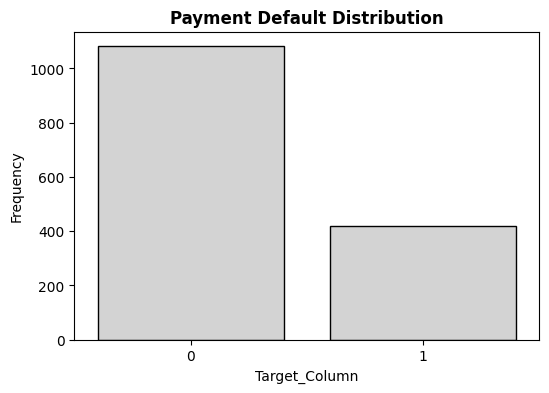

In [ ]:


# Count Plot
plt.figure(figsize=(6,4))
sns.countplot(x="Target_Column" , data=df, edgecolor="black", color="lightgray")

plt.title("Payment Default Distribution", fontweight="bold")
plt.xlabel("Target_Column")
plt.ylabel("Frequency")
plt.show()

The count plot shows the distribution of customers based on Target_Column.

Most customers have Target_Column = 0, while fewer customers have Target_Column = 1.

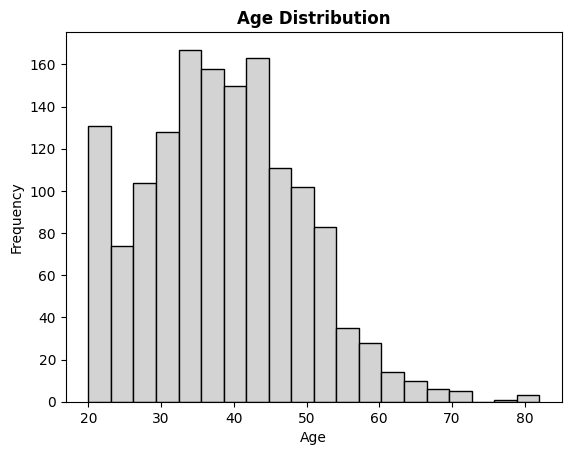

In [ ]:
#Histogram

plt.hist(df["Age"], bins=20, edgecolor="black", color="lightgray")
plt.title("Age Distribution", fontweight="bold")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

The histogram shows the distribution of Age.

Most customers are concentrated between 25 and 45 years old, while the remaining customers are distributed across older age groups.

The values range approximately from 20 to 82.

/tmp/ipykernel_1037/2660345912.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Target_Column", y="Age", data=df, palette="Set2")


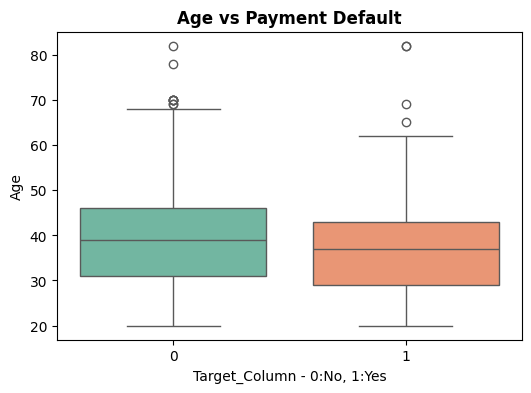

In [ ]:
#Box Plot

sns.boxplot(x="Target_Column", y="Age", data=df, palette="Set2")
plt.title("Age vs Payment Default", fontweight="bold")
plt.xlabel("Target_Column - 0:No, 1:Yes")
plt.ylabel("Age")
plt.show()

The box plot shows the comparison of Age between customers who defaulted and those who did not (Target_Column: 0 = No, 1 = Yes).

Both groups (Non-defaulters and Defaulters) have a similar median age of around 38 years.

The middle 50% of customers in both categories fall within the age range of 31 to 45 years.

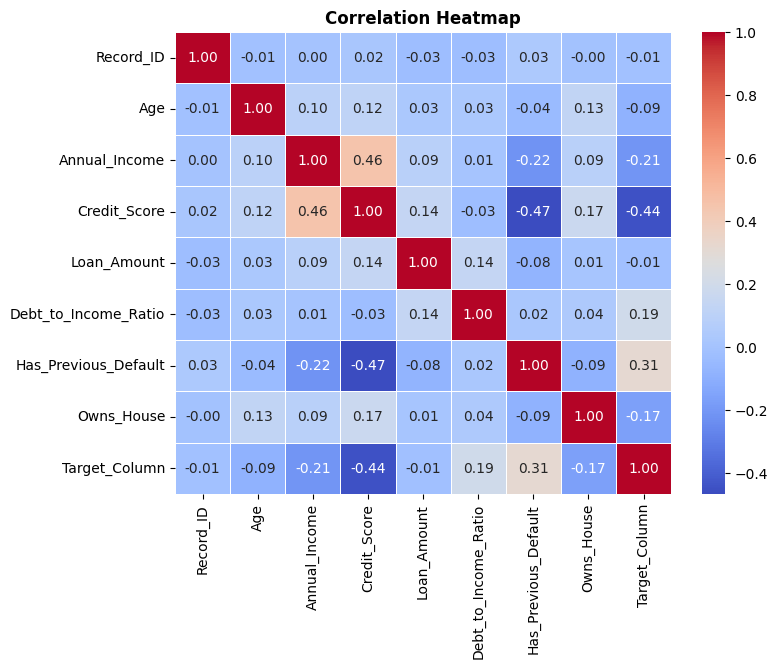

In [ ]:

#Hetmap
numeric_df = df.select_dtypes(include="number")

plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

plt.title("Correlation Heatmap", fontweight="bold")
plt.show()

The values in the heatmap range from -1 to +1

Warm colors (like red) represent positive correlation, while cool colors (like blue) represent negative or weak correlation.

In [ ]:

df.drop_duplicates(inplace=True)
df.head()

,Record_ID,Age,Annual_Income,Credit_Score,Loan_Amount,Debt_to_Income_Ratio,Employment_Type,Region,Has_Previous_Default,Owns_House,Account_Open_Date,Target_Column
0,100821,29.0,42519.15,520.0,16283.72,NaN,Salaried,West,0,0,2019-01-05,1
1,100058,51.0,56301.50,609.0,28567.71,54.31,Self-Employed,South,0,1,2024-12-27,1
2,100972,37.0,65326.52,713.0,12033.37,23.14,Salaried,North,0,1,2020-10-24,0
3,100670,35.0,59021.99,598.0,23246.10,32.19,Salaried,West,0,0,2024-09-05,1
4,100739,33.0,50408.54,587.0,16845.28,43.03,Salaried,North,0,0,2018-12-01,0


There were 30 duplicate rows in the dataset. The duplicate rows were removed using drop_duplicates().

In [ ]:
df["Loan_Amount"] = pd.to_numeric(df["Loan_Amount"], errors="coerce")
df

,Record_ID,Age,Annual_Income,Credit_Score,Loan_Amount,Debt_to_Income_Ratio,Employment_Type,Region,Has_Previous_Default,Owns_House,Account_Open_Date,Target_Column
0,100821,29.0,42519.15,520.0,16283.72,NaN,Salaried,West,0,0,2019-01-05,1
1,100058,51.0,56301.50,609.0,28567.71,54.31,Self-Employed,South,0,1,2024-12-27,1
2,100972,37.0,65326.52,713.0,12033.37,23.14,Salaried,North,0,1,2020-10-24,0
3,100670,35.0,59021.99,598.0,23246.10,32.19,Salaried,West,0,0,2024-09-05,1
4,100739,33.0,50408.54,587.0,16845.28,43.03,Salaried,North,0,0,2018-12-01,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1495,101093,27.0,50633.21,585.0,11967.78,16.61,Salaried,East,0,0,2018-12-18,0
1496,101193,37.0,46760.78,701.0,19879.84,32.73,Business Owner,South,0,0,2018-04-14,0
1497,101210,49.0,55878.94,603.0,13454.39,28.08,Salaried,South,0,0,2019-02-26,1
1498,101060,42.0,66507.79,619.0,18524.47,31.26,Self-Employed,East,1,1,2018-04-08,0


The tenure column was converted from string to integer format. After conversion, 26 missing values were identified. These missing values were handled using median imputation.

In [ ]:

# Numerical Columns
numeric_features = ["Age", "Annual_Income", "Credit_Score", "Loan_Amount", "Debt_to_Income_Ratio"]

# Categorical Columns
categorical_features = ["Employment_Type", "Region", "Has_Previous_Default", "Owns_House"]

df[numeric_features] = df[numeric_features].fillna(df[numeric_features].mean())


The dataset contains 5 numerical features and 4 categorical features. Missing values in numerical features are imputed using the mean. Numerical features are selected for scaling, while categorical features are selected for One-Hot Encoding."

In [ ]:
X_num = df[numeric_features]
X_cat = df[categorical_features]
Y = df["Target_Column"]

The numerical and categorical features were separated into two groups. X_num contains the numerical features, while X_cat contains the categorical features.

In [ ]:
# Handle Missing Value
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

X_num = pd.DataFrame(
    imputer.fit_transform(X_num),
    columns=numeric_features
)

The missing values in numerical columns were filled using the median value. After imputation, the numerical data was ready for further preprocessing.

In [ ]:
# Feature Scaling
scaler = StandardScaler()

X_num_scaled = pd.DataFrame(
    scaler.fit_transform(X_num),
    columns=numeric_features
)

The numerical features were scaled using StandardScaler. This brings the numerical features to a common scale for better model performance.

In [ ]:
# OneHotEncoder
encoder = OneHotEncoder(sparse_output=False,handle_unknown="ignore")

X_cat_encoded = encoder.fit_transform(X_cat)

encoded_columns = encoder.get_feature_names_out(categorical_features)

X_cat_encoded = pd.DataFrame(
    X_cat_encoded,
    columns=encoded_columns
)

The categorical features were converted into numerical format using OneHotEncoder. The categorical columns were converted into separate binary columns for model training

In [ ]:
#target variable
print(df["Target_Column"].value_counts())

Target_Column
0    1058
1     412
Name: count, dtype: int64


In [ ]:
# Combine All Features
X_final = pd.concat(
    [X_num_scaled, X_cat_encoded],
    axis=1
)
X_final

,Age,Annual_Income,Credit_Score,Loan_Amount,Debt_to_Income_Ratio,Employment_Type_Business Owner,Employment_Type_Business Owner,Employment_Type_SALARIED,Employment_Type_SELF-EMPLOYED,Employment_Type_Salaried,...,Region_West,Region_east,Region_north,Region_south,Region_west,Region_nan,Has_Previous_Default_0,Has_Previous_Default_1,Owns_House_0,Owns_House_1
0,-0.901778,-0.469159,-1.276160,-0.195330,0.000000,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,1.186094,-0.090554,-0.139693,0.094214,0.779907,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
2,-0.142552,0.157366,1.188314,-0.295514,-0.715112,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
3,-0.332359,-0.015822,-0.280155,-0.031221,-0.281043,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
4,-0.522165,-0.252436,-0.420617,-0.182093,0.238880,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,-1.091585,-0.246264,-0.446156,-0.297060,-1.028313,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1466,-0.142552,-0.352641,1.035082,-0.110566,-0.255143,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1467,0.996287,-0.102162,-0.216309,-0.262019,-0.478173,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1468,0.331964,0.189815,-0.012000,-0.142514,-0.325649,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0


In [ ]:
#Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_final,
    y,
    test_size=0.2,
    random_state=42
)

print(f"Training data shape: X={X_train.shape}, y={y_train.shape}")
print(f"Testing data shape: X={X_test.shape}, y={y_test.shape}")

Training data shape: X=(1176, 37), y=(1176,)
Testing data shape: X=(294, 37), y=(294,)


In [ ]:
print("=== Model Parameters ===")
print(model.get_params())

print("\n=== Fitted Attributes ===")
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

=== Model Parameters ===
{'C': 1.0, 'class_weight': None, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': None, 'max_iter': 100, 'multi_class': 'deprecated', 'n_jobs': None, 'penalty': 'l2', 'random_state': None, 'solver': 'lbfgs', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}

=== Fitted Attributes ===
Coefficients: [[-0.05151608 -0.14760898 -0.97252169  0.02221947  0.56294271  0.54182772
  -0.04586428 -0.79635932 -0.24123607 -0.25674639 -0.17967891 -0.09293538
  -0.06178782  0.64028023  0.1569991   0.37191527  0.64259798  0.
  -0.52649341 -0.23338961  0.04827992 -0.27519674  0.45832463  0.17359503
  -0.5129912   0.23832216 -0.33680563 -0.01462334  0.63462092 -0.09985297
  -0.27940037 -0.41204222  0.29689891 -0.28499257  0.20412168  0.26104731
  -0.3419182 ]]
Intercept: [-0.97631238]


In [ ]:
# Model Training
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [ ]:
print(model.coef_)
print(model.intercept_)

[[-0.05151608 -0.14760898 -0.97252169  0.02221947  0.56294271  0.54182772
  -0.04586428 -0.79635932 -0.24123607 -0.25674639 -0.17967891 -0.09293538
  -0.06178782  0.64028023  0.1569991   0.37191527  0.64259798  0.
  -0.52649341 -0.23338961  0.04827992 -0.27519674  0.45832463  0.17359503
  -0.5129912   0.23832216 -0.33680563 -0.01462334  0.63462092 -0.09985297
  -0.27940037 -0.41204222  0.29689891 -0.28499257  0.20412168  0.26104731
  -0.3419182 ]]
[-0.97631238]


In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import ( accuracy_score, precision_score, recall_score, f1_score, roc_auc_score)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

# Precision
precision = precision_score(y_test, y_pred)

# Recall
recall = recall_score(y_test, y_pred)

# F1 Score
f1 = f1_score(y_test, y_pred)

# ROC-AUC
y_prob = model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_prob)

print("--- Logistic Regression Evaluation Metrics ---")
print(f"Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

--- Logistic Regression Evaluation Metrics ---
Accuracy:  0.8027 (80.27%)
Precision: 0.7111
Recall:    0.4156
F1 Score:  0.5246


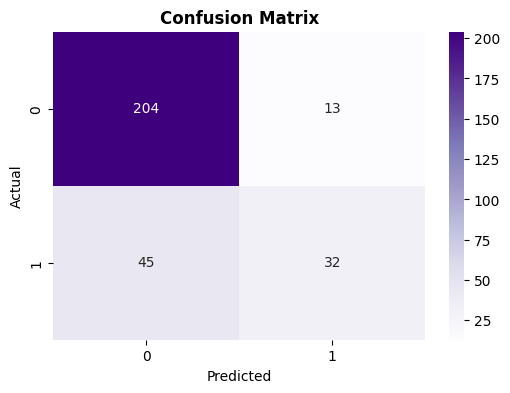

In [ ]:
# Confusion matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples")
plt.title("Confusion Matrix", fontweight="bold")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

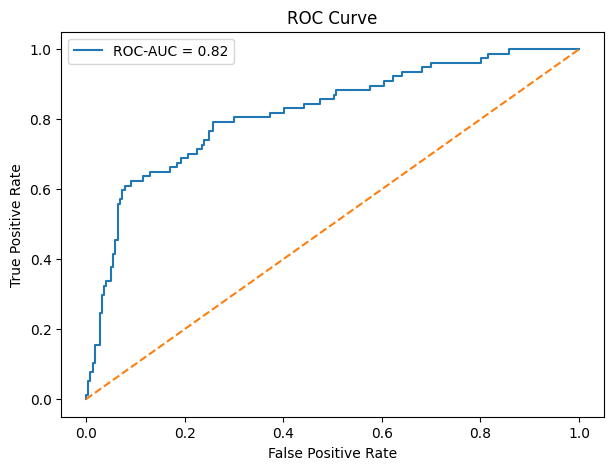

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

# Predicted probabilities for Class 1
y_prob = model.predict_proba(X_test)[:, 1]

# Calculate False Positive Rate and True Positive Rate
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Calculate ROC-AUC
roc_auc = roc_auc_score(y_test, y_prob)

# Plot ROC Curve
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [ ]:
coefficients = model.coef_[0]

feature_names = X_final.columns

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

coef_df.sort_values(
    by="Coefficient",
    ascending=False
)

,Feature,Coefficient
16,Employment_Type_salaried,0.642598
13,Employment_Type_UNEMPLOYED,0.640280
28,Region_east,0.634621
4,Debt_to_Income_Ratio,0.562943
5,Employment_Type_Business Owner,0.541828
22,Region_NORTH,0.458325
15,Employment_Type_business owner,0.371915
32,Region_nan,0.296899
35,Owns_House_0,0.261047
25,Region_South,0.238322
